In [244]:
# Import library yang dibutuhkan
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


In [245]:
# Folder input: hasil ekstraksi fitur
EKSTRAKSI_DIR = Path("../hasil_ekstraksi")

# Folder output: hasil klasifikasi
KLASIFIKASI_DIR = Path("../hasil_klasifikasi")
KLASIFIKASI_DIR.mkdir(parents=True, exist_ok=True)

# Mapping nama preprocessing dan file CSV hasil ekstraksi
PREPO_CONFIG = {
    "prepo1_resize+grayscale": "hasil_ekstraksi_prepo1.csv",
    "prepo2_resize+grayscale+median": "hasil_ekstraksi_prepo2.csv",
    "prepo3_resize+grayscale+median+equ": "hasil_ekstraksi_prepo3.csv",
    "prepo4_resize+grayscale+median+sobel": "hasil_ekstraksi_prepo4.csv",
    "prepo5_resize+grayscale+median+sobel+thresholding": "hasil_ekstraksi_prepo5.csv"
}

print("Folder hasil ekstraksi:", EKSTRAKSI_DIR.resolve())
print("Folder hasil klasifikasi:", KLASIFIKASI_DIR.resolve())

print("\nCek file CSV:")
for prepo_name, csv_name in PREPO_CONFIG.items():
    csv_path = EKSTRAKSI_DIR / csv_name
    print(prepo_name, "->", "ADA" if csv_path.exists() else "TIDAK ADA", "|", csv_path)


Folder hasil ekstraksi: D:\AAAAA KULIAH\SEM 4\PECEDE\Project-PCD-Kelompok-16\hasil_ekstraksi
Folder hasil klasifikasi: D:\AAAAA KULIAH\SEM 4\PECEDE\Project-PCD-Kelompok-16\hasil_klasifikasi

Cek file CSV:
prepo1_resize+grayscale -> ADA | ..\hasil_ekstraksi\hasil_ekstraksi_prepo1.csv
prepo2_resize+grayscale+median -> ADA | ..\hasil_ekstraksi\hasil_ekstraksi_prepo2.csv
prepo3_resize+grayscale+median+equ -> ADA | ..\hasil_ekstraksi\hasil_ekstraksi_prepo3.csv
prepo4_resize+grayscale+median+sobel -> ADA | ..\hasil_ekstraksi\hasil_ekstraksi_prepo4.csv
prepo5_resize+grayscale+median+sobel+thresholding -> ADA | ..\hasil_ekstraksi\hasil_ekstraksi_prepo5.csv


In [246]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print("Accuracy:", accuracy_score(y_true, y_pred))


In [247]:
def feature_selection_template(hasilEkstrak, threshold=0.95, show_heatmap=False, title="Korelasi Fitur"):
    # Kolom yang bukan fitur
    drop_columns = ["Label", "Filename", "Preprocessing"]
    drop_columns = [col for col in drop_columns if col in hasilEkstrak.columns]

    # Ambil fitur numerik
    feature_data = hasilEkstrak.drop(columns=drop_columns)
    feature_data = feature_data.select_dtypes(include=[np.number])

    # Menghitung korelasi
    correlation_matrix = feature_data.corr()

    # Menyaring fitur yang memiliki korelasi lebih dari threshold
    columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

    for i in range(correlation_matrix.shape[0]):
        for j in range(i + 1, correlation_matrix.shape[0]):
            if correlation_matrix.iloc[i, j] >= threshold:
                if columns[j]:
                    columns[j] = False

    selected_columns = feature_data.columns[columns]

    x_new = hasilEkstrak[selected_columns]
    y = hasilEkstrak["Label"]

    if show_heatmap:
        plt.figure(figsize=(17, 17))
        sns.heatmap(x_new.corr(), annot=True, cmap="Blues", fmt=".2f")
        plt.title(title)
        plt.show()

    return x_new, y, selected_columns


In [248]:
def normalisasi_mean_std(X_train, X_test):
    # Menghindari pembagian dengan 0 jika ada fitur yang standar deviasinya 0
    std_train = X_train.std().replace(0, 1)

    X_test_norm = (X_test - X_train.mean()) / std_train
    X_train_norm = (X_train - X_train.mean()) / std_train

    return X_train_norm, X_test_norm


In [249]:
def klasifikasi_satu_prepo(prepo_name, csv_path, show_heatmap=False):
    print("=" * 80)
    print("Preprocessing:", prepo_name)
    print("CSV:", csv_path)
    print("=" * 80)

    # Membaca hasil ekstraksi fitur
    hasilEkstrak = pd.read_csv(csv_path)

    print("Jumlah data:", len(hasilEkstrak))
    print("Distribusi label:")
    print(hasilEkstrak["Label"].value_counts())
    print()

    # Feature selection
    x_new, y, selected_columns = feature_selection_template(
        hasilEkstrak,
        threshold=0.95,
        show_heatmap=show_heatmap,
        title=f"Korelasi Fitur - {prepo_name}"
    )

    print("Jumlah fitur awal:", len([
        col for col in hasilEkstrak.columns
        if col not in ["Label", "Filename", "Preprocessing"]
    ]))
    print("Jumlah fitur setelah selection:", len(selected_columns))
    print("Fitur yang digunakan:")
    print(list(selected_columns))
    print()

    # Splitting data
    X_train, X_test, y_train, y_test = train_test_split(
        x_new,
        y,
        test_size=0.3,
        random_state=90
    )

    print("Shape X_train:", X_train.shape)
    print("Shape X_test:", X_test.shape)
    print()

    # Normalisasi mean std
    X_train, X_test = normalisasi_mean_std(X_train, X_test)

    # Define classifiers sesuai template
    models = {
        "Random Forest": RandomForestClassifier(n_estimators=5, random_state=42),
        "SVM": SVC(kernel="rbf", random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5)
    }

    hasil_model = []
    trained_models = {}
    predictions = {}

    for model_name, model in models.items():
        print("-" * 80)
        print("Model:", model_name)
        print("-" * 80)

        # Train model
        model.fit(X_train, y_train)
        trained_models[model_name] = model

        # Evaluasi training set
        print("------Training Set------")
        y_pred_train = model.predict(X_train)
        generateClassificationReport(y_train, y_pred_train)

        # Evaluasi testing set
        print("\n------Testing Set------")
        y_pred_test = model.predict(X_test)
        generateClassificationReport(y_test, y_pred_test)

        predictions[model_name] = {
            "y_test": y_test,
            "y_pred_test": y_pred_test
        }

        hasil_model.append({
            "Preprocessing": prepo_name,
            "Model": model_name,
            "Train Accuracy": accuracy_score(y_train, y_pred_train),
            "Test Accuracy": accuracy_score(y_test, y_pred_test),
            "Precision": precision_score(y_test, y_pred_test, average="weighted", zero_division=0),
            "Recall": recall_score(y_test, y_pred_test, average="weighted", zero_division=0),
            "F1-Score": f1_score(y_test, y_pred_test, average="weighted", zero_division=0),
            "Total Data": len(hasilEkstrak),
            "Jumlah Fitur Awal": len([
                col for col in hasilEkstrak.columns
                if col not in ["Label", "Filename", "Preprocessing"]
            ]),
            "Jumlah Fitur Setelah Selection": len(selected_columns)
        })

        print()

    result_df = pd.DataFrame(hasil_model)

    return {
        "prepo_name": prepo_name,
        "data": hasilEkstrak,
        "x_new": x_new,
        "y": y,
        "selected_columns": selected_columns,
        "result_df": result_df,
        "trained_models": trained_models,
        "predictions": predictions,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }


In [250]:
hasil_semua_prepo = {}
ringkasan_klasifikasi = []

for prepo_name, csv_name in PREPO_CONFIG.items():
    csv_path = EKSTRAKSI_DIR / csv_name

    if not csv_path.exists():
        print(f"File tidak ditemukan: {csv_path}")
        continue

    hasil = klasifikasi_satu_prepo(prepo_name, csv_path, show_heatmap=False)
    hasil_semua_prepo[prepo_name] = hasil
    ringkasan_klasifikasi.append(hasil["result_df"])

df_ringkasan = pd.concat(ringkasan_klasifikasi, ignore_index=True)

df_ringkasan


Preprocessing: prepo1_resize+grayscale
CSV: ..\hasil_ekstraksi\hasil_ekstraksi_prepo1.csv
Jumlah data: 140
Distribusi label:
Label
catterpillar    70
snail           70
Name: count, dtype: int64

Jumlah fitur awal: 28
Jumlah fitur setelah selection: 10
Fitur yang digunakan:
['Contrast0', 'Homogeneity0', 'Dissimilarity0', 'Entropy0', 'ASM0', 'Energy0', 'Correlation0', 'Contrast45', 'Dissimilarity45', 'Correlation45']

Shape X_train: (98, 10)
Shape X_test: (42, 10)

--------------------------------------------------------------------------------
Model: Random Forest
--------------------------------------------------------------------------------
------Training Set------
              precision    recall  f1-score   support

catterpillar       0.98      0.94      0.96        52
       snail       0.94      0.98      0.96        46

    accuracy                           0.96        98
   macro avg       0.96      0.96      0.96        98
weighted avg       0.96      0.96      0.96        

,Preprocessing,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,Total Data,Jumlah Fitur Awal,Jumlah Fitur Setelah Selection
0,prepo1_resize+grayscale,Random Forest,0.959184,0.809524,0.809753,0.809524,0.807731,140,28,10
1,prepo1_resize+grayscale,SVM,0.857143,0.904762,0.918367,0.904762,0.902473,140,28,10
2,prepo1_resize+grayscale,KNN,0.846939,0.833333,0.848806,0.833333,0.827754,140,28,10
3,prepo2_resize+grayscale+median,Random Forest,0.969388,0.738095,0.748299,0.738095,0.739438,140,28,14
4,prepo2_resize+grayscale+median,SVM,0.826531,0.904762,0.907280,0.904762,0.903866,140,28,14
5,prepo2_resize+grayscale+median,KNN,0.867347,0.952381,0.956044,0.952381,0.951933,140,28,14
6,prepo3_resize+grayscale+median+equ,Random Forest,0.948980,0.738095,0.740438,0.738095,0.738848,140,28,12
7,prepo3_resize+grayscale+median+equ,SVM,0.816327,0.880952,0.901478,0.880952,0.876967,140,28,12
8,prepo3_resize+grayscale+median+equ,KNN,0.795918,0.833333,0.837037,0.833333,0.830660,140,28,12
9,prepo4_resize+grayscale+median+sobel,Random Forest,0.989796,0.666667,0.666667,0.666667,0.666667,140,28,14


In [251]:
output_ringkasan = KLASIFIKASI_DIR / "hasil_klasifikasi_semua_prepo.csv"
df_ringkasan.to_csv(output_ringkasan, index=False)

print("Hasil klasifikasi berhasil disimpan ke:", output_ringkasan.resolve())
df_ringkasan


Hasil klasifikasi berhasil disimpan ke: D:\AAAAA KULIAH\SEM 4\PECEDE\Project-PCD-Kelompok-16\hasil_klasifikasi\hasil_klasifikasi_semua_prepo.csv


,Preprocessing,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,Total Data,Jumlah Fitur Awal,Jumlah Fitur Setelah Selection
0,prepo1_resize+grayscale,Random Forest,0.959184,0.809524,0.809753,0.809524,0.807731,140,28,10
1,prepo1_resize+grayscale,SVM,0.857143,0.904762,0.918367,0.904762,0.902473,140,28,10
2,prepo1_resize+grayscale,KNN,0.846939,0.833333,0.848806,0.833333,0.827754,140,28,10
3,prepo2_resize+grayscale+median,Random Forest,0.969388,0.738095,0.748299,0.738095,0.739438,140,28,14
4,prepo2_resize+grayscale+median,SVM,0.826531,0.904762,0.907280,0.904762,0.903866,140,28,14
5,prepo2_resize+grayscale+median,KNN,0.867347,0.952381,0.956044,0.952381,0.951933,140,28,14
6,prepo3_resize+grayscale+median+equ,Random Forest,0.948980,0.738095,0.740438,0.738095,0.738848,140,28,12
7,prepo3_resize+grayscale+median+equ,SVM,0.816327,0.880952,0.901478,0.880952,0.876967,140,28,12
8,prepo3_resize+grayscale+median+equ,KNN,0.795918,0.833333,0.837037,0.833333,0.830660,140,28,12
9,prepo4_resize+grayscale+median+sobel,Random Forest,0.989796,0.666667,0.666667,0.666667,0.666667,140,28,14


In [252]:
df_akurasi = df_ringkasan.copy()
df_akurasi["Test Accuracy (%)"] = df_akurasi["Test Accuracy"] * 100
df_akurasi["Train Accuracy (%)"] = df_akurasi["Train Accuracy"] * 100

df_akurasi_tampil = df_akurasi[[
    "Preprocessing",
    "Model",
    "Train Accuracy (%)",
    "Test Accuracy (%)",
    "Precision",
    "Recall",
    "F1-Score"
]]

df_akurasi_tampil


,Preprocessing,Model,Train Accuracy (%),Test Accuracy (%),Precision,Recall,F1-Score
0,prepo1_resize+grayscale,Random Forest,95.918367,80.952381,0.809753,0.809524,0.807731
1,prepo1_resize+grayscale,SVM,85.714286,90.476190,0.918367,0.904762,0.902473
2,prepo1_resize+grayscale,KNN,84.693878,83.333333,0.848806,0.833333,0.827754
3,prepo2_resize+grayscale+median,Random Forest,96.938776,73.809524,0.748299,0.738095,0.739438
4,prepo2_resize+grayscale+median,SVM,82.653061,90.476190,0.907280,0.904762,0.903866
5,prepo2_resize+grayscale+median,KNN,86.734694,95.238095,0.956044,0.952381,0.951933
6,prepo3_resize+grayscale+median+equ,Random Forest,94.897959,73.809524,0.740438,0.738095,0.738848
7,prepo3_resize+grayscale+median+equ,SVM,81.632653,88.095238,0.901478,0.880952,0.876967
8,prepo3_resize+grayscale+median+equ,KNN,79.591837,83.333333,0.837037,0.833333,0.830660
9,prepo4_resize+grayscale+median+sobel,Random Forest,98.979592,66.666667,0.666667,0.666667,0.666667


In [253]:
best_result = df_ringkasan.loc[df_ringkasan["Test Accuracy"].idxmax()]

print("Model terbaik:")
print("Preprocessing :", best_result["Preprocessing"])
print("Model         :", best_result["Model"])
print("Akurasi Test  :", round(best_result["Test Accuracy"] * 100, 2), "%")
print("Precision     :", round(best_result["Precision"], 4))
print("Recall        :", round(best_result["Recall"], 4))
print("F1-Score      :", round(best_result["F1-Score"], 4))


Model terbaik:
Preprocessing : prepo2_resize+grayscale+median
Model         : KNN
Akurasi Test  : 95.24 %
Precision     : 0.956
Recall        : 0.9524
F1-Score      : 0.9519


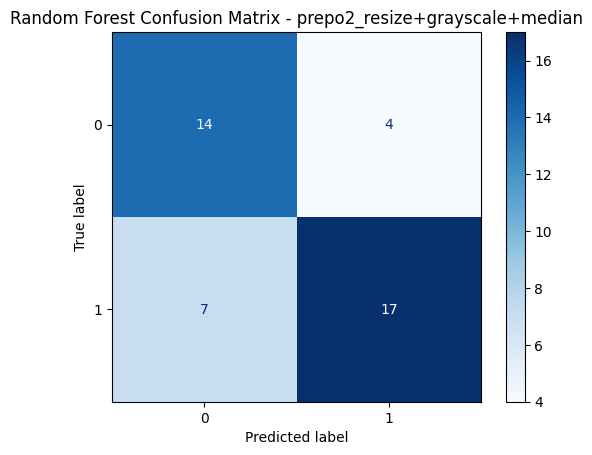

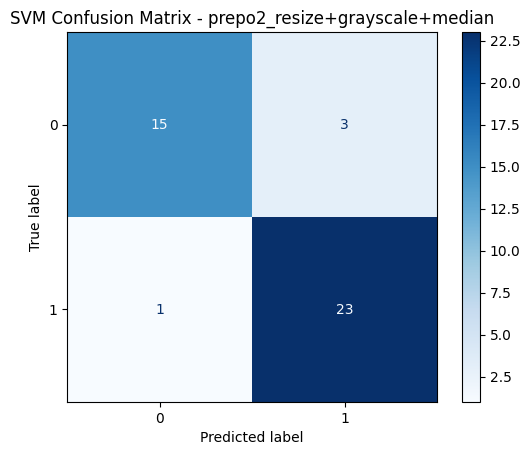

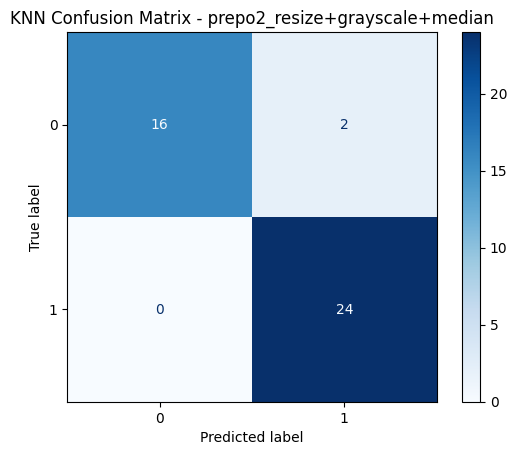

In [254]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()


best_prepo = best_result["Preprocessing"]
hasil_best = hasil_semua_prepo[best_prepo]

for model_name, pred_data in hasil_best["predictions"].items():
    plot_confusion_matrix(
        pred_data["y_test"],
        pred_data["y_pred_test"],
        f"{model_name} Confusion Matrix - {best_prepo}"
    )


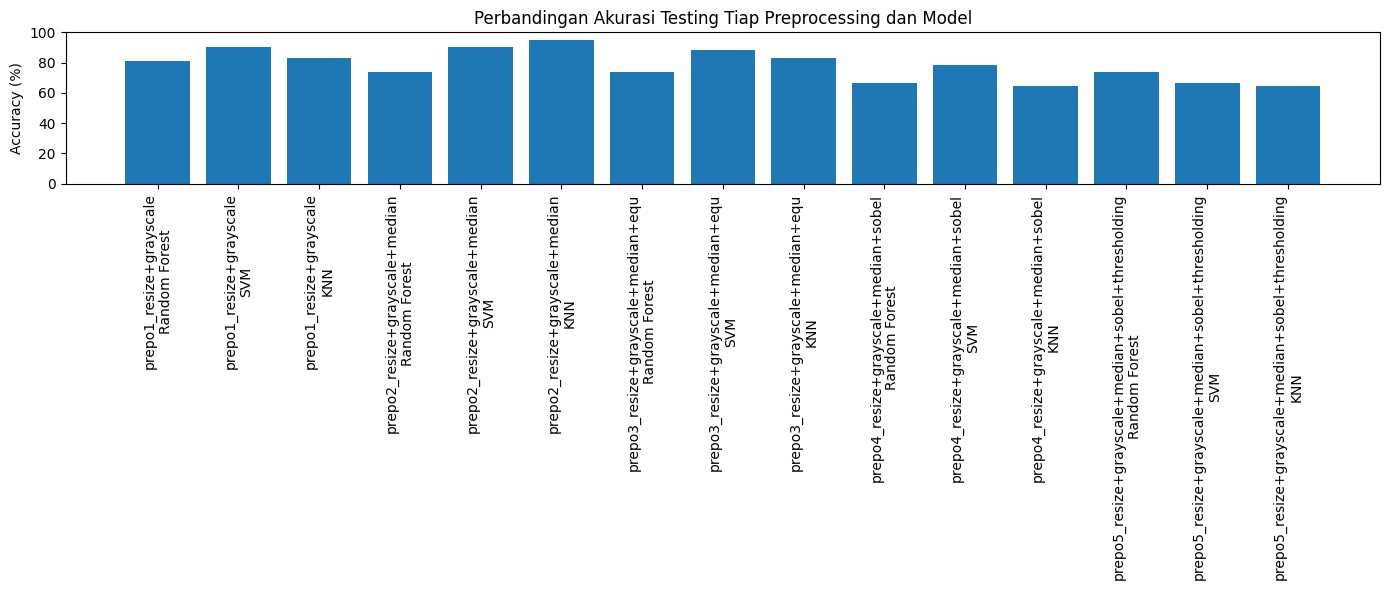

In [255]:
plt.figure(figsize=(14, 6))

plot_data = df_ringkasan.copy()
plot_data["Kombinasi"] = plot_data["Preprocessing"] + "\n" + plot_data["Model"]
plot_data["Test Accuracy (%)"] = plot_data["Test Accuracy"] * 100

plt.bar(plot_data["Kombinasi"], plot_data["Test Accuracy (%)"])
plt.xticks(rotation=90)
plt.ylabel("Accuracy (%)")
plt.title("Perbandingan Akurasi Testing Tiap Preprocessing dan Model")
plt.tight_layout()
plt.show()


In [256]:
print(
    f"Berdasarkan hasil klasifikasi, kombinasi terbaik diperoleh pada "
    f"{best_result['Preprocessing']} menggunakan model {best_result['Model']} "
    f"dengan akurasi testing sebesar {best_result['Test Accuracy'] * 100:.2f}%."
)


Berdasarkan hasil klasifikasi, kombinasi terbaik diperoleh pada prepo2_resize+grayscale+median menggunakan model KNN dengan akurasi testing sebesar 95.24%.
